In [5]:
!head ratings_long.csv

'head' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
r = np.full((20, 1000),fill_value=np.nan)

In [8]:
df = pd.read_csv('ratings_long.csv')

In [9]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [10]:
r

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(20, 1000))

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

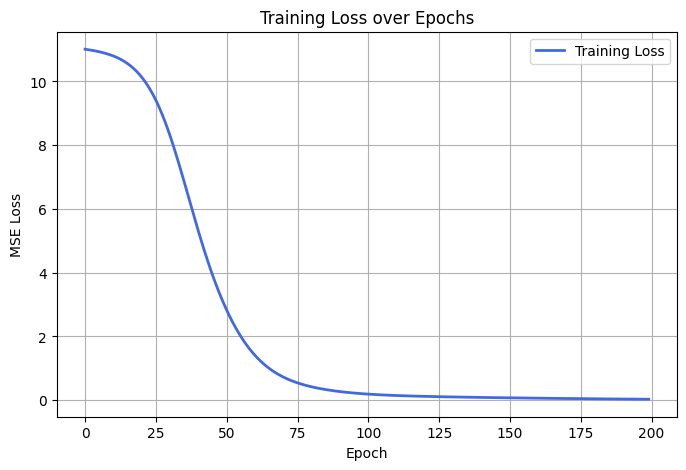

In [21]:
np.random.seed(42)
u = np.random.rand(20, 4) * 0.1
v = np.random.rand(4, 1000) * 0.1

epochs = 200
lr = 0.005
lambda_ = 0.01 
losses = []

known_indices = np.argwhere(~np.isnan(r))

for epoch in range(epochs):
    total_loss = 0

    for userId, movieId in known_indices:
        rating = r[userId, movieId]
        prediction = u[userId] @ v[:, movieId]
        error = rating - prediction

        total_loss += error ** 2

        old_u = u[userId].copy()
        old_v = v[:, movieId].copy()

        u[userId]     += lr * (error * old_v - lambda_ * old_u)
        v[:, movieId] += lr * (error * old_u - lambda_ * old_v)

    mse = total_loss / len(known_indices)
    losses.append(mse)

plt.figure(figsize=(8, 5))
plt.plot(losses, color='royalblue', linewidth=2, label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()
